# Notebook 02 - Batch 1 Metadata Analysis

## Objective

This notebook analyzes the clinical metadata corresponding to the CT scans
available in Batch 1 of the PANORAMA public dataset.

The notebook will:

- Load clinical metadata
- Match Batch 1 patient IDs
- Analyze class distribution
- Analyze demographic information
- Analyze acquisition characteristics
- Generate tables and figures for the thesis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
OUTPUT_DIR = Path(r"D:\Pancreatic_Cancer_Thesis\outputs")

In [ ]:
DATA_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis\data")

metadata_path = DATA_ROOT / "metadata" / "clinical_information.xlsx"
ct_path = DATA_ROOT / "raw_ct"

In [ ]:
metadata = pd.read_excel(metadata_path)

print("Rows:", len(metadata))
print("Columns:", len(metadata.columns))

metadata.head()

Rows: 2238
Columns: 8


,PANORAMA_patient_id,PANORAMA_study_id,anonymized_study_date,patient_age,patient_sex,scanner,label,level
0,100000,100000_00001,2018-10-04,042Y,F,TOSHIBA,non-PDAC,radiology
1,100001,100001_00001,2014-04-24,068Y,M,SIEMENS,non-PDAC,radiology
2,100002,100002_00001,2021-03-02,077Y,F,TOSHIBA,PDAC,pathology
3,100003,100003_00001,2016-12-28,057Y,M,TOSHIBA,PDAC,cytology
4,100004,100004_00001,2018-02-09,068Y,M,SIEMENS,non-PDAC,radiology


In [ ]:
print(metadata.columns.tolist())

['PANORAMA_patient_id', 'PANORAMA_study_id', 'anonymized_study_date', 'patient_age', 'patient_sex', 'scanner', 'label', 'level']


In [ ]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 2238 entries, 0 to 2237
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   PANORAMA_patient_id    2238 non-null   int64         
 1   PANORAMA_study_id      2238 non-null   str           
 2   anonymized_study_date  2044 non-null   datetime64[us]
 3   patient_age            1964 non-null   str           
 4   patient_sex            1964 non-null   str           
 5   scanner                1962 non-null   str           
 6   label                  2238 non-null   str           
 7   level                  2238 non-null   str           
dtypes: datetime64[us](1), int64(1), str(6)
memory usage: 140.0 KB


In [ ]:
metadata.isnull().sum().sort_values(ascending=False)

scanner                  276
patient_age              274
patient_sex              274
anonymized_study_date    194
PANORAMA_patient_id        0
PANORAMA_study_id          0
label                      0
level                      0
dtype: int64

In [ ]:
print(metadata["PANORAMA_study_id"].head().tolist())

['100000_00001', '100001_00001', '100002_00001', '100003_00001', '100004_00001']


In [ ]:
print("Duplicate rows:", metadata.duplicated().sum())

Duplicate rows: 0


In [ ]:
metadata.describe(include="all")

,PANORAMA_patient_id,PANORAMA_study_id,anonymized_study_date,patient_age,patient_sex,scanner,label,level
count,2238.000000,2238,2044,1964,1964,1962,2238,2238
unique,NaN,2238,NaN,82,2,6,2,7
top,NaN,100000_00001,NaN,067Y,M,SIEMENS,non-PDAC,radiology
freq,NaN,1,NaN,83,1064,938,1562,1212
mean,101108.772118,NaN,2016-12-17 22:12:12.681017,NaN,NaN,NaN,NaN,NaN
min,100000.000000,NaN,2004-01-29 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,100549.250000,NaN,2015-08-16 00:00:00,NaN,NaN,NaN,NaN,NaN
50%,101108.500000,NaN,2016-10-06 12:00:00,NaN,NaN,NaN,NaN,NaN
75%,101665.750000,NaN,2018-08-01 06:00:00,NaN,NaN,NaN,NaN,NaN
max,102223.000000,NaN,2023-06-03 00:00:00,NaN,NaN,NaN,NaN,NaN


In [ ]:
metadata.to_csv(
    DATA_ROOT / "metadata" / "generated" / "clinical_information_clean.csv",
    index=False
)

print("Saved!")

Saved!


In [ ]:
metadata.columns.tolist()

['PANORAMA_patient_id',
 'PANORAMA_study_id',
 'anonymized_study_date',
 'patient_age',
 'patient_sex',
 'scanner',
 'label',
 'level']

label
non-PDAC    1562
PDAC         676
Name: count, dtype: int64


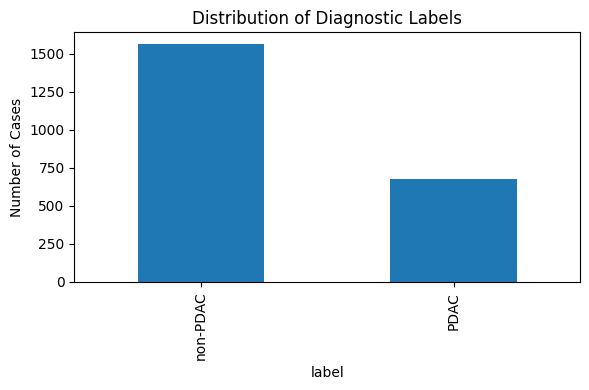

In [ ]:
label_counts = metadata["label"].value_counts()

print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")
plt.title("Distribution of Diagnostic Labels")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

level
radiology           1212
histopathology       353
pathology            210
MSD_dataset          194
cytology             183
NIH_dataset           80
radiology / 3yFU       6
Name: count, dtype: int64


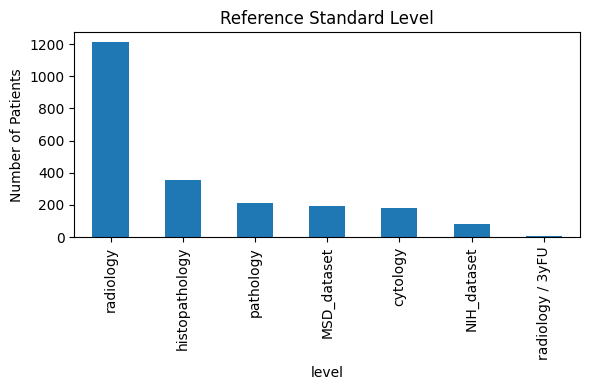

In [ ]:
level_counts = metadata["level"].value_counts()

print(level_counts)

plt.figure(figsize=(6,4))
level_counts.plot(kind="bar")
plt.title("Reference Standard Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

patient_sex
M      1064
F       900
NaN     274
Name: count, dtype: int64


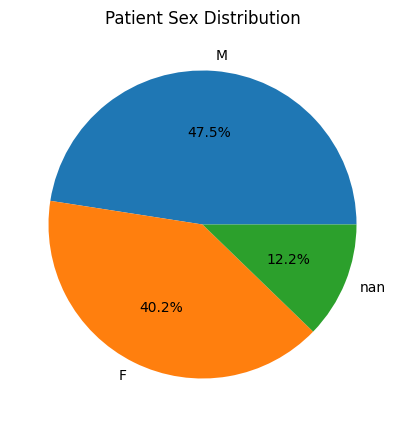

In [ ]:
sex_counts = metadata["patient_sex"].value_counts(dropna=False)

print(sex_counts)

plt.figure(figsize=(5,5))
sex_counts.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Patient Sex Distribution")
plt.show()

In [ ]:
metadata["age_years"] = (
    metadata["patient_age"]
    .str.replace("Y", "", regex=False)
    .astype("float")
)

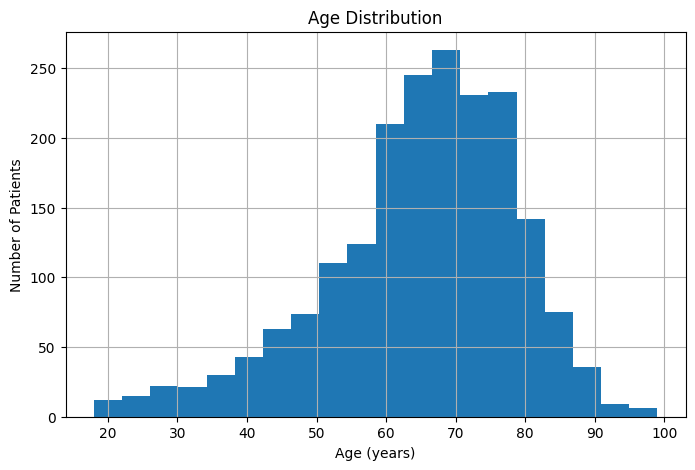

In [ ]:
plt.figure(figsize=(8,5))

metadata["age_years"].hist(bins=20)

plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")

plt.show()

In [ ]:
metadata["age_years"].describe()

count    1964.000000
mean       64.809572
std        13.685962
min        18.000000
25%        58.000000
50%        67.000000
75%        75.000000
max        99.000000
Name: age_years, dtype: float64

scanner
SIEMENS                  938
TOSHIBA                  651
Philips                  319
GE MEDICAL SYSTEMS        46
Canon Medical Systems      7
0                          1
Name: count, dtype: int64


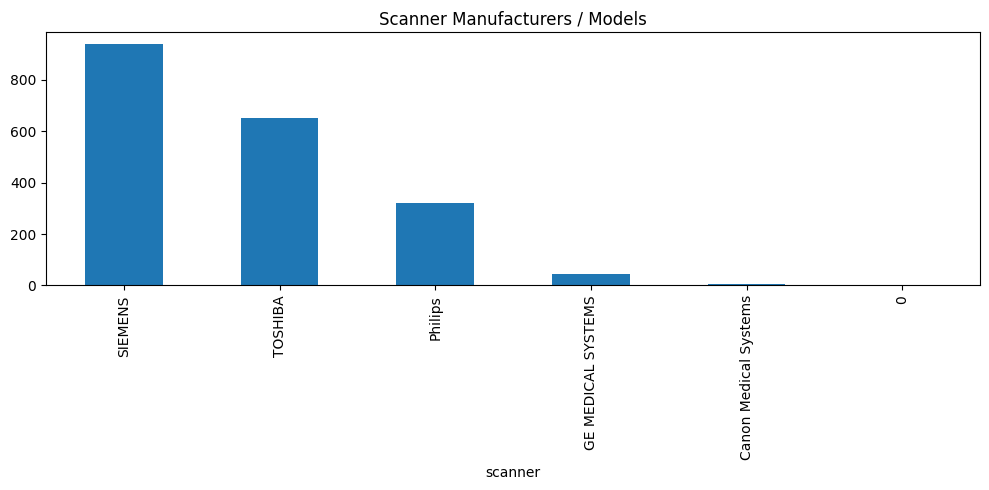

In [ ]:
scanner_counts = metadata["scanner"].value_counts()

print(scanner_counts)

plt.figure(figsize=(10,5))

scanner_counts.plot(kind="bar")

plt.title("Scanner Manufacturers / Models")

plt.tight_layout()

plt.show()

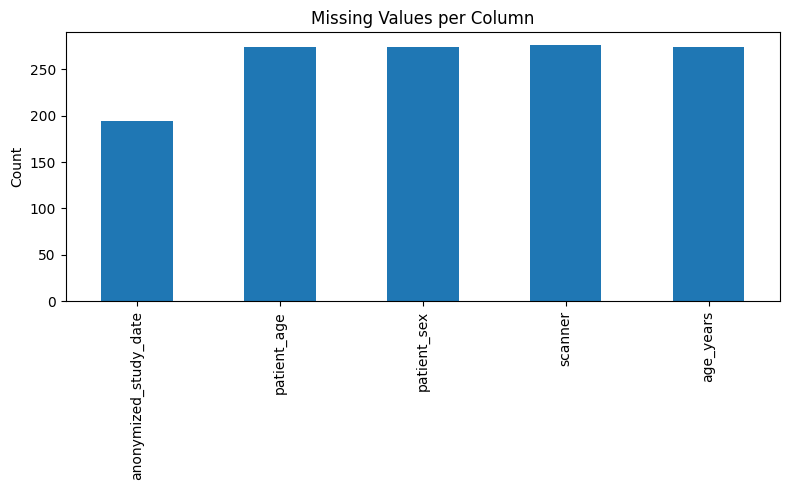

In [ ]:
missing = metadata.isnull().sum()

missing = missing[missing > 0]

missing.plot(kind="bar")

plt.title("Missing Values per Column")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [ ]:
from pathlib import Path

ct_files = list(ct_path.glob("*.nii.gz"))

print("CT files:", len(ct_files))

CT files: 557


In [ ]:
ct_ids = {
    f.stem.replace("_0000", "")
    for f in ct_files
}

metadata_ids = set(metadata["PANORAMA_study_id"])

print("Metadata entries:", len(metadata_ids))

Metadata entries: 2238


In [ ]:
missing_metadata = ct_ids - metadata_ids

print("CT scans without metadata:", len(missing_metadata))

CT scans without metadata: 557


In [ ]:
missing_ct = metadata_ids - ct_ids

print("Metadata without CT:", len(missing_ct))

Metadata without CT: 2238


In [ ]:
label_counts.to_csv(
    OUTPUT_DIR / "label_distribution.csv"
)

scanner_counts.to_csv(
    OUTPUT_DIR / "scanner_distribution.csv"
)

print("Summary tables saved.")

Summary tables saved.


In [ ]:
metadata[metadata["scanner"] == "0"]

,PANORAMA_patient_id,PANORAMA_study_id,anonymized_study_date,patient_age,patient_sex,scanner,label,level,age_years
1169,101159,101159_00001,2020-12-05,069Y,M,0,PDAC,histopathology,69.0


In [ ]:
metadata["scanner"] = metadata["scanner"].replace(0, "Unknown")
metadata["scanner"] = metadata["scanner"].replace("0", "Unknown")

Data Quality Note: One patient had the scanner field recorded as 0. This value was treated as Unknown for descriptive analysis. The CT image and diagnostic label were retained because the missing scanner manufacturer does not affect image interpretation or model training.

In [ ]:
scanner_counts = metadata["scanner"].value_counts()

print(scanner_counts)

scanner
SIEMENS                  938
TOSHIBA                  651
Philips                  319
GE MEDICAL SYSTEMS        46
Canon Medical Systems      7
Unknown                    1
Name: count, dtype: int64
